# Field classification: strata and pattern (donor) fields

Assign fields to groundwater-access strata (REM + stream type) and identify
non-irrigated pattern fields for ET_gwsm donor matching.

| Step | Input | Output |
|------|-------|--------|
| 1. Stratify | `fields_bounds.fgb`, `rem_bounds.tif`, `flowlines_bounds.fgb` | `fields_stratified.fgb` |
| 2. Pattern (IrrMapper) | `fields_stratified.fgb`, IrrMapper CSV | `fields_pattern.fgb` |

In [1]:
# Shared color palette
STREAM_BLUE = '#2171b5'
WET_CMAP    = 'Blues'
TERRAIN_CMAP = 'terrain'
REM_CMAP    = 'RdYlBu_r'
NDWI_CMAP   = 'RdYlGn'
STRATA_COLORS = {
    'perennial':      '#2166ac',
    'intermittent':   '#74add1',
    'managed':        '#4dac26',
    'non_partitioned':'#d9d9d9',
}
PARTITION_COLORS = {'pe':'#a6cee3','et_gwsm':'#1f78b4','et_irr':'#e31a1c'}


## 1. Setup

In [2]:
import collections
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import rioxarray as rxr
import tomllib

from handily.config import HandilyConfig
from handily.nhd import classify_flowlines, FCODE_CATEGORIES
from handily.stratify import stratify
from handily.pattern import assign_pattern_from_irrmapper, assign_pattern_by_strata
from handily.et.irrmapper import load_irrigation_frequency, identify_pattern_candidates

config_path = Path('beaverhead_config.toml')
with open(config_path, 'rb') as f:
    cfg = tomllib.load(f)

config  = HandilyConfig.from_dict(cfg)
out_dir = os.path.expanduser(config.out_dir)
print('Output directory:', out_dir)


Output directory: /nas/handily/handily/beaverhead/outputs/


## 2. Load NB02 outputs

These files were produced by `02_terrain_analysis.ipynb`.

In [3]:
fields_path    = os.path.join(out_dir, 'fields_bounds.fgb')
flowlines_path = os.path.join(out_dir, 'flowlines_bounds.fgb')
rem_path       = os.path.join(out_dir, 'rem_bounds.tif')

fields    = gpd.read_file(fields_path)
flowlines = gpd.read_file(flowlines_path)
rem_da    = rxr.open_rasterio(rem_path, masked=True).squeeze('band', drop=True)

print(f'Fields:    {len(fields)} polygons  columns={list(fields.columns)}')
print(f'Flowlines: {len(flowlines)} segments')
print(f'REM:       {rem_da.shape}  range {float(rem_da.min()):.1f}–{float(rem_da.max()):.1f} m')


Fields:    48 polygons  columns=['FID_', 'SOURCECODE', 'COUNTY_NO', 'COUNTYNAME', 'ITYPE', 'USAGE', 'MAPPEDBY', 'rem_mean', 'geometry']
Flowlines: 253 segments
REM:       (5798, 5864)  range 0.0–12.7 m


## 3. Stratification

`stratify()` runs four steps:
1. REM zonal stats → `rem_mean` (skipped if already in `fields_bounds.fgb`)
2. `rem_mean < rem_threshold` → `partitioned` (bool)
3. Classify NHD flowlines by FCODE category
4. Nearest-stream assignment → `nearest_stream_type` + final `strata`

In [4]:
fields_stratified = stratify(
    fields=fields,
    flowlines=flowlines,
    rem_da=rem_da,
    rem_threshold=config.rem_threshold,
)

print('Strata distribution:')
print(fields_stratified['strata'].value_counts().to_string())

# Save
strat_path = os.path.join(out_dir, 'fields_stratified.fgb')
fields_stratified.to_file(strat_path, driver='FlatGeobuf')
print(f'\nSaved → {strat_path}')


Unmapped FCODE values (will be excluded): [55800]


Strata distribution:
strata
non_partitioned    35
managed             6
intermittent        5
perennial           2

Saved → /nas/handily/handily/beaverhead/outputs/fields_stratified.fgb


### REM-based partitioning

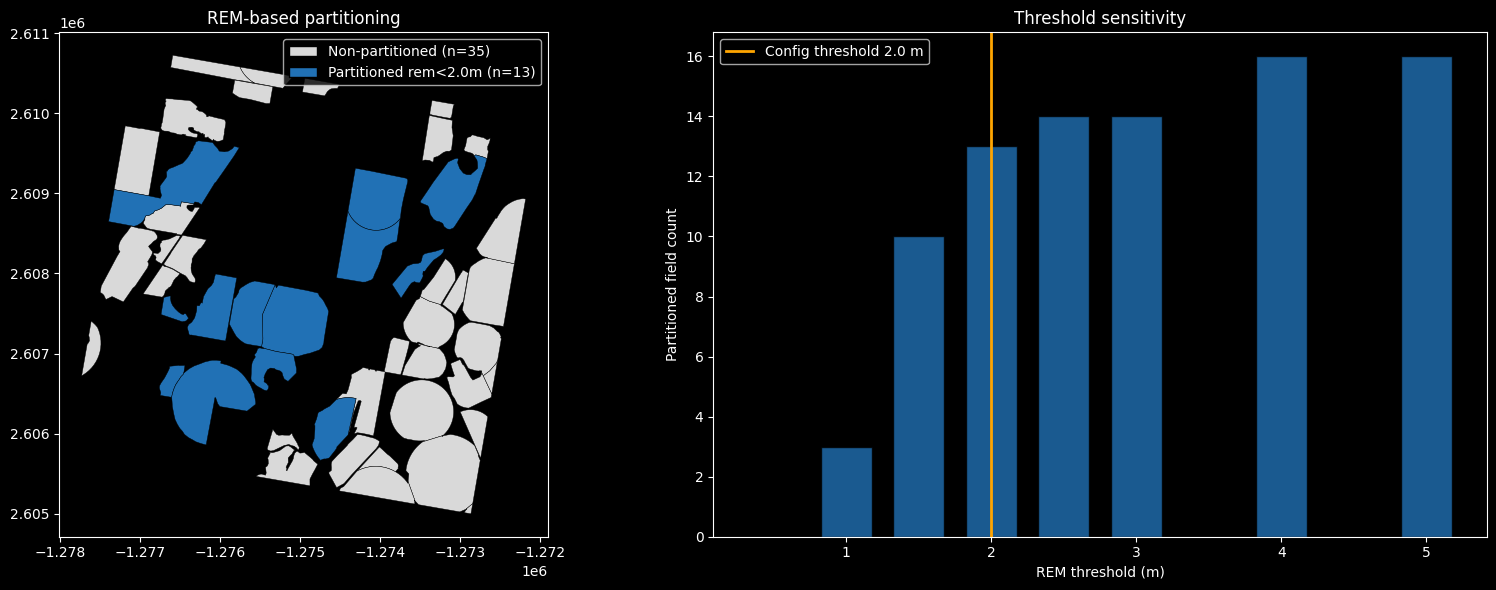

In [5]:
threshold = config.rem_threshold
n_part    = fields_stratified['partitioned'].sum()
n_nopart  = (~fields_stratified['partitioned']).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Map
for is_part, color, label in [
    (False, '#d9d9d9', f'Non-partitioned (n={n_nopart})'),
    (True,  '#2171b5', f'Partitioned rem<{threshold}m (n={n_part})'),
]:
    fields_stratified[fields_stratified['partitioned'] == is_part].plot(
        ax=axes[0], color=color, edgecolor='black', linewidth=0.3)
handles = [
    mpatches.Patch(facecolor='#d9d9d9', edgecolor='black', label=f'Non-partitioned (n={n_nopart})'),
    mpatches.Patch(facecolor='#2171b5', edgecolor='black', label=f'Partitioned rem<{threshold}m (n={n_part})'),
]
axes[0].legend(handles=handles); axes[0].set_title('REM-based partitioning')

# Threshold sensitivity
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
counts = [(fields_stratified['rem_mean'] < t).sum() for t in thresholds]
axes[1].bar(thresholds, counts, width=0.35, color=STREAM_BLUE, edgecolor='black', alpha=0.8)
axes[1].axvline(threshold, color='orange', linewidth=2, label=f'Config threshold {threshold} m')
axes[1].set_xlabel('REM threshold (m)'); axes[1].set_ylabel('Partitioned field count')
axes[1].set_title('Threshold sensitivity'); axes[1].legend()
plt.tight_layout(); plt.show()


## 4. NHD flowline classification

Unmapped FCODE values (will be excluded): [55800]


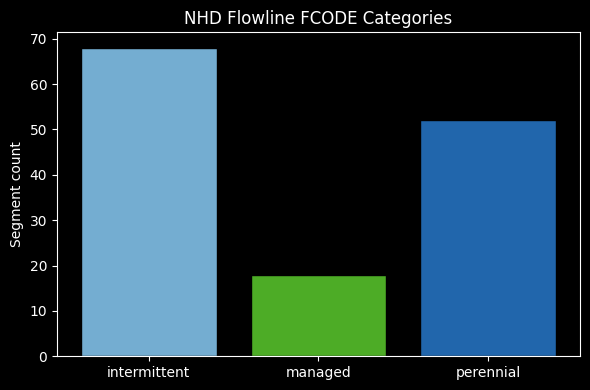

Flowline categories: {'intermittent': 68, 'managed': 18, 'perennial': 52}


In [6]:
fcode_col = next((c for c in flowlines.columns if c.lower() == 'fcode'), None)
flowlines_cls = classify_flowlines(flowlines)

# FCODE category bar chart — filter None (unclassified codes) and 'unknown'
cats = [FCODE_CATEGORIES.get(fc) for fc in flowlines[fcode_col]]
counts = collections.Counter(c for c in cats if c is not None)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(),
       color=[STRATA_COLORS.get(k, '#aaa') for k in counts.keys()], edgecolor='black')
ax.set_title('NHD Flowline FCODE Categories')
ax.set_ylabel('Segment count')
plt.tight_layout(); plt.show()
print(f'Flowline categories: {dict(counts)}')


### Nearest stream type per field

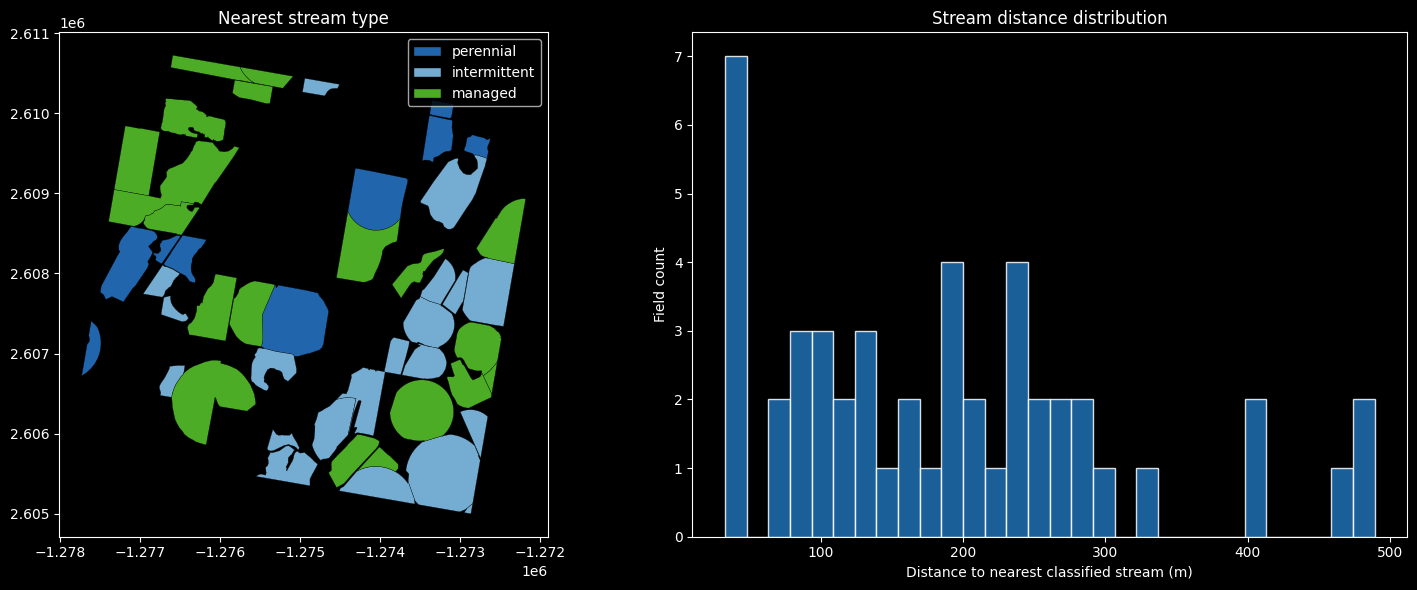

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: map colored by nearest_stream_type
for stype, color in STRATA_COLORS.items():
    mask = fields_stratified['nearest_stream_type'] == stype
    if mask.any():
        fields_stratified[mask].plot(ax=axes[0], color=color, edgecolor='black', linewidth=0.2)
handles = [mpatches.Patch(facecolor=c, edgecolor='black', label=s)
           for s, c in STRATA_COLORS.items()
           if (fields_stratified['nearest_stream_type'] == s).any()]
axes[0].legend(handles=handles); axes[0].set_title('Nearest stream type')

# Right: stream distance histogram
if 'stream_distance' in fields_stratified.columns:
    axes[1].hist(fields_stratified['stream_distance'].dropna(), bins=30,
                 color=STREAM_BLUE, edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Distance to nearest classified stream (m)')
    axes[1].set_ylabel('Field count')
    axes[1].set_title('Stream distance distribution')
plt.tight_layout(); plt.show()


### Strata map

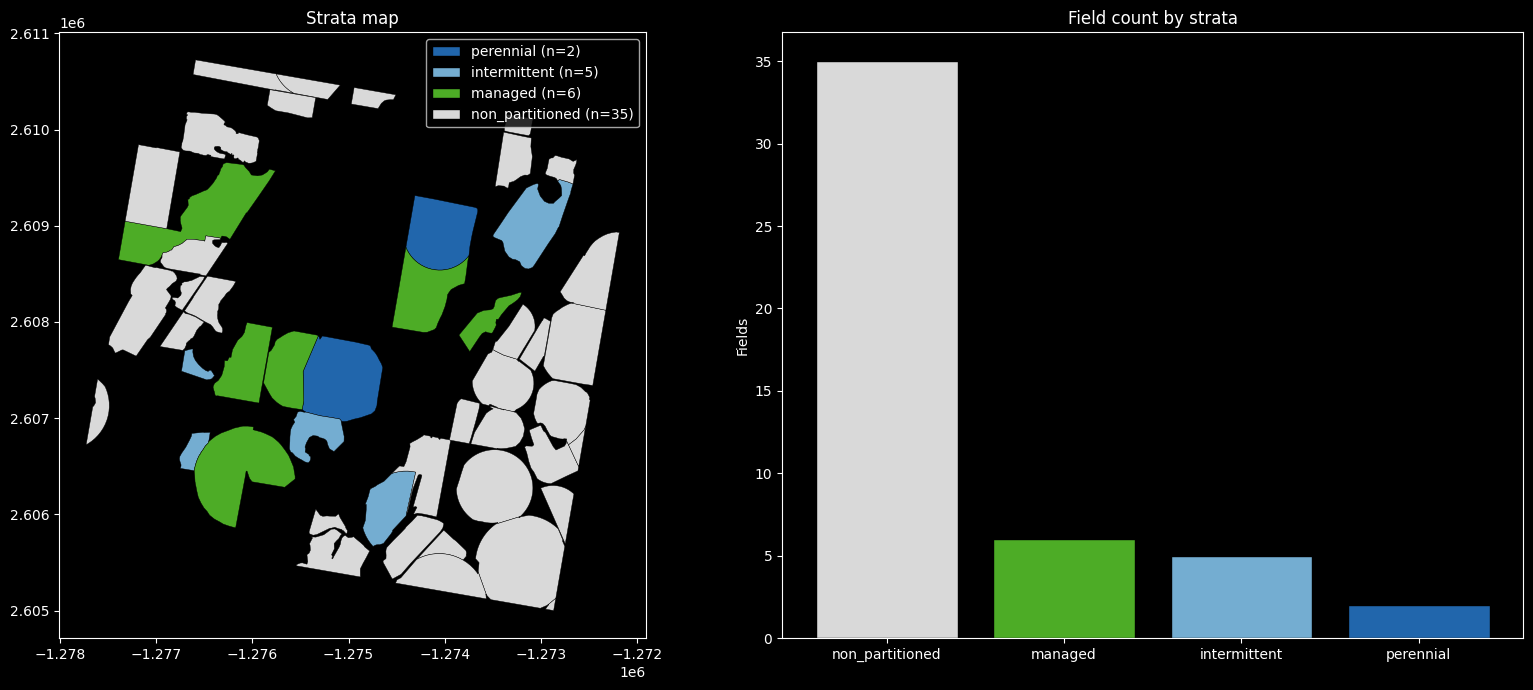

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: choropleth
for strata, color in STRATA_COLORS.items():
    sub = fields_stratified[fields_stratified['strata'] == strata]
    if len(sub):
        sub.plot(ax=axes[0], color=color, edgecolor='black', linewidth=0.3)
handles = [mpatches.Patch(facecolor=c, edgecolor='black',
                           label=f'{s} (n={( fields_stratified["strata"]==s).sum()})')
           for s, c in STRATA_COLORS.items()]
axes[0].legend(handles=handles, loc='best'); axes[0].set_title('Strata map')

# Right: count bar
strata_counts = fields_stratified['strata'].value_counts()
axes[1].bar(strata_counts.index, strata_counts.values,
            color=[STRATA_COLORS.get(s, '#aaa') for s in strata_counts.index],
            edgecolor='black')
axes[1].set_title('Field count by strata'); axes[1].set_ylabel('Fields')
plt.tight_layout(); plt.show()


## 5. IrrMapper irrigation history

IrrMapper is an annual Landsat irrigation classification (1987–present).
We sync the Earth Engine export from GCS and summarise irrigation frequency
per field for pattern candidate selection.

> **Export** (run once from Earth Engine or via `handily ee-export`):
> ```python
> from handily.et.irrmapper import export_irrigation_frequency
> export_irrigation_frequency(fields_stratified, desc='beaverhead',
>     dest='bucket', bucket=config.et_bucket)
> ```
> The export runs asynchronously; re-run the sync cell once it completes.

### Sync from GCS bucket

In [9]:
from handily.bucket import sync_irrmapper

csv_path = sync_irrmapper(
    project_name=config.project_name,
    local_root=config.local_data_root,
    bucket=config.et_bucket,
    bucket_prefix=config.bucket_prefix,
    dry_run=False,
)

# Fall back to config path if sync found nothing new
if csv_path is None and config.irrmapper_csv and os.path.exists(config.irrmapper_csv):
    csv_path = config.irrmapper_csv

print(f'IrrMapper CSV: {csv_path}')
assert csv_path is not None and os.path.exists(csv_path), \
    'IrrMapper CSV not found. Run EE export and sync first.'


IrrMapper CSV: /nas/handily/handily/beaverhead/irrmapper/beaverhead_FID_irr_freq.csv


### Load IrrMapper and assign pattern column

In [10]:
irr_stats = load_irrigation_frequency(csv_path, feature_id='FID')
irr_candidates = identify_pattern_candidates(
    irr_stats,
    max_irr_freq=cfg.get('max_irr_freq', 0.1),
    max_irr_mean=cfg.get('max_irr_mean', 0.05),
)

print(f'IrrMapper loaded: {len(irr_stats)} fields')
print(f"irr_freq  mean={irr_stats['irr_freq'].mean():.3f}  "
      f"median={irr_stats['irr_freq'].median():.3f}")
print(f"Pattern candidates: {irr_candidates['pattern_candidate'].sum()} "
      f"/ {len(irr_candidates)} "
      f"({100*irr_candidates['pattern_candidate'].mean():.1f}%)")


IrrMapper loaded: 48 fields
irr_freq  mean=0.987  median=1.000
Pattern candidates: 0 / 48 (0.0%)


In [11]:
fields_with_irr = assign_pattern_from_irrmapper(
    fields_stratified,
    irrmapper_csv=csv_path,
    feature_id='FID',
    max_irr_freq=cfg.get('max_irr_freq', 0.1),
    max_irr_mean=cfg.get('max_irr_mean', 0.05),
)

# Ensure minimum donors per strata
fields_pattern = assign_pattern_by_strata(fields_with_irr, min_per_strata=1)

n_pattern   = fields_pattern['pattern'].sum()
n_irrigated = (~fields_pattern['pattern']).sum()
print(f'Pattern donors:  {n_pattern}')
print(f'Irrigated fields: {n_irrigated}')
print(fields_pattern.groupby('strata')['pattern'].sum().rename('donors').to_string())

pattern_path = os.path.join(out_dir, 'fields_pattern.fgb')
fields_pattern.to_file(pattern_path, driver='FlatGeobuf')
print(f'\nSaved → {pattern_path}')


Pattern donors:  3
Irrigated fields: 45
strata
intermittent       1
managed            1
non_partitioned    0
perennial          1

Saved → /nas/handily/handily/beaverhead/outputs/fields_pattern.fgb


### IrrMapper: irrigation frequency scatter

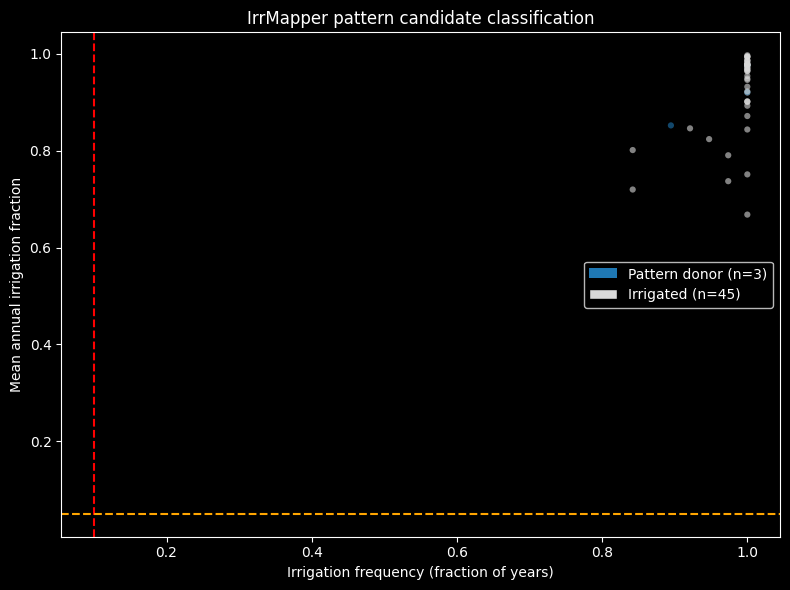

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = fields_pattern['pattern'].map({True: '#1f78b4', False: '#d9d9d9'})
ax.scatter(fields_pattern['irr_freq'], fields_pattern['irr_mean'],
           c=colors, alpha=0.6, s=20, edgecolors='none')
ax.axvline(cfg.get('max_irr_freq', 0.1), color='red', linestyle='--',
           label=f"max_irr_freq={cfg.get('max_irr_freq', 0.1)}")
ax.axhline(cfg.get('max_irr_mean', 0.05), color='orange', linestyle='--',
           label=f"max_irr_mean={cfg.get('max_irr_mean', 0.05)}")
handles = [
    mpatches.Patch(facecolor='#1f78b4', label=f'Pattern donor (n={n_pattern})'),
    mpatches.Patch(facecolor='#d9d9d9', edgecolor='black', label=f'Irrigated (n={n_irrigated})'),
]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0][2:], framealpha=0.9)
ax.set_xlabel('Irrigation frequency (fraction of years)')
ax.set_ylabel('Mean annual irrigation fraction')
ax.set_title('IrrMapper pattern candidate classification')
plt.tight_layout(); plt.show()


### Pattern field map

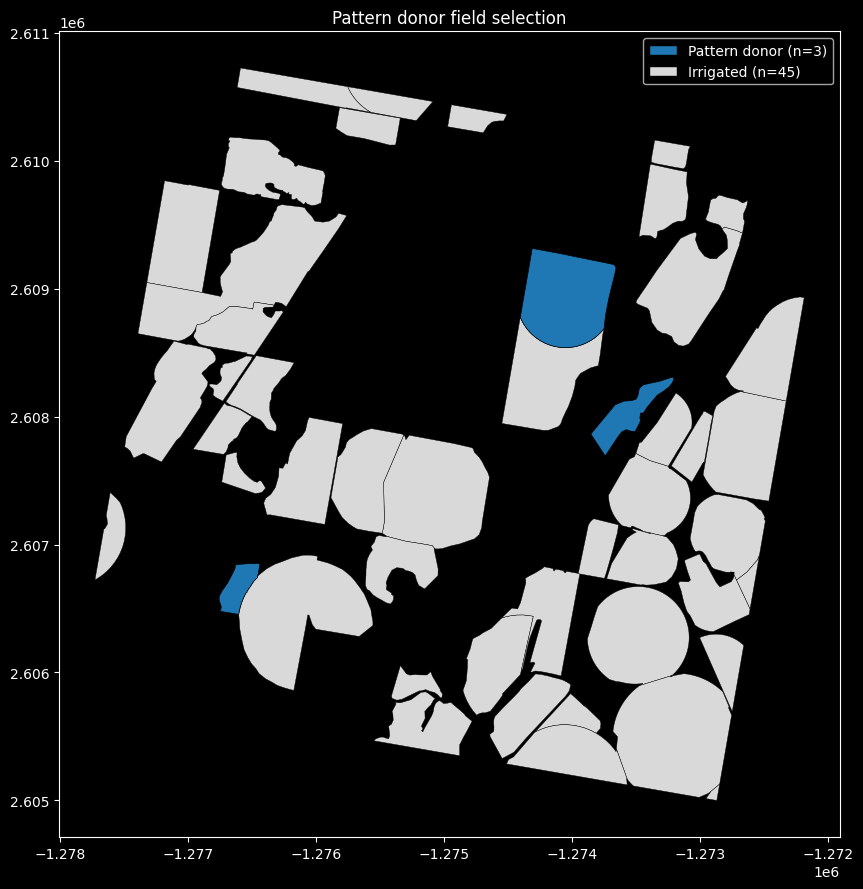

In [13]:
fig, ax = plt.subplots(figsize=(12, 9))

fields_pattern[~fields_pattern['pattern']].plot(
    ax=ax, color='#d9d9d9', edgecolor='black', linewidth=0.3)
fields_pattern[fields_pattern['pattern']].plot(
    ax=ax, color='#1f78b4', edgecolor='black', linewidth=0.5)

handles = [
    mpatches.Patch(facecolor='#1f78b4', edgecolor='black', label=f'Pattern donor (n={n_pattern})'),
    mpatches.Patch(facecolor='#d9d9d9', edgecolor='black', label=f'Irrigated (n={n_irrigated})'),
]
ax.legend(handles=handles)
ax.set_title('Pattern donor field selection')
plt.tight_layout(); plt.show()


### Donor readiness by strata

In [14]:
from IPython.display import display

summary = fields_pattern.groupby('strata')['pattern'].sum().rename('Pattern Donors').reset_index()
totals  = fields_pattern['strata'].value_counts().rename('Total Fields').reset_index()
totals.columns = ['strata', 'Total Fields']
summary = summary.merge(totals, on='strata')
summary['Donor %'] = (100 * summary['Pattern Donors'] / summary['Total Fields']).round(1)
summary.columns = ['Strata', 'Pattern Donors', 'Total Fields', 'Donor %']
display(summary)


,Strata,Pattern Donors,Total Fields,Donor %
0,intermittent,1,5,20.0
1,managed,1,6,16.7
2,non_partitioned,0,35,0.0
3,perennial,1,2,50.0


### Output files

| File | Description |
|------|-------------|
| `fields_stratified.fgb` | `partitioned`, `nearest_stream_type`, `strata` |
| `fields_pattern.fgb` | + `irr_mean`, `irr_freq`, `pattern` |

## Key takeaways

- Strata constrain donor matching to comparable groundwater-access setting (REM) and water-source type.
- IrrMapper provides an empirical screen for stable non-irrigated pattern fields.
- Bucket mirroring + `handily sync` keeps Earth Engine exports consistent with local paths.

**Next**: [Notebook 06 — Climate and ET](06_climate_and_et.ipynb)

> **Repo Capability — Notebook 3 (Field Classification)**
> Modules: `handily.stratify`, `handily.nhd`, `handily.pattern`, `handily.bucket`, `handily.et.irrmapper`
> Key functions: `stratify()`, `assign_pattern_from_irrmapper()`, `assign_pattern_by_strata()`, `sync_irrmapper()`
> CLI: `handily sync --subdir irrmapper`

> **Artifacts Produced**
> - `fields_stratified.fgb` — stratified field polygons
> - `fields_pattern.fgb` — pattern donor assignments